# Network Intrusion Detection Using Machine Learning Models
**A Project in CST9L — College of Computing Education, The University of Mindanao**
**Group 14:** Lhoreneil I. Jose and Julian Carlo Cabaobao  |  1st Semester, 1st Term S.Y. 2026-2027

This notebook is the code for the project paper. It follows the same order as the paper's Methodology and Results sections:

1. Setup and dataset loading
2. Data understanding
3. Data cleaning
4. Data transformation
5. Feature engineering
6. Feature selection
7. Training and testing the Random Forest
8. Evaluation (accuracy, precision, recall, F1-score, confusion matrix, false-positive rate)
9. Feature importance
10. Effect of preprocessing steps (supporting experiment)
11. Prediction confidence
12. Project demonstration (model producing predictions)
13. Save the model and conclusion

**Run all cells from top to bottom** (Runtime > Run all). Estimated time: about 5 to 8 minutes on a free Colab runtime.

## Project Summary
- **Problem:** Classify network connections as **Normal, DoS, Probe, R2L, or U2R**.
- **Dataset:** NSL-KDD (`KDDTrain+` for training, `KDDTest+` for testing).
- **Learning type:** Supervised, multiclass classification.
- **Model:** Random Forest Classifier (scikit-learn).
- **Evaluation:** accuracy, precision, recall, F1-score, confusion matrix, false-positive rate, feature importance.

## 1. Setup and Dataset Loading

In [1]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                             confusion_matrix, classification_report, f1_score, recall_score)

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
pd.set_option("display.max_columns", 50)
print("Libraries loaded.")

Libraries loaded.


The NSL-KDD files (`KDDTrain+.txt` and `KDDTest+.txt`) are the same benchmark files published on Kaggle ([hassan06/nslkdd](https://www.kaggle.com/datasets/hassan06/nslkdd)). Kaggle needs a login to download, so the cell below pulls the same two files from a public GitHub mirror.

**Using your own Kaggle copy instead?** Upload `KDDTrain+.txt` and `KDDTest+.txt` to the Colab *Files* panel (left sidebar) into a folder named `data`, then skip the `wget` lines.

In [2]:
os.makedirs("data", exist_ok=True)
BASE = "https://raw.githubusercontent.com/defcom17/NSL_KDD/master"
for name in ["KDDTrain%2B.txt", "KDDTest%2B.txt"]:
    target = "data/" + name.replace("%2B", "+")
    if not os.path.exists(target):
        !wget -q -O "{target}" "{BASE}/{name}"
print(os.listdir("data"))

['KDDTrain+.txt', 'KDDTest+.txt']


In [3]:
columns = ["duration","protocol_type","service","flag","src_bytes","dst_bytes","land","wrong_fragment",
 "urgent","hot","num_failed_logins","logged_in","num_compromised","root_shell","su_attempted","num_root",
 "num_file_creations","num_shells","num_access_files","num_outbound_cmds","is_host_login","is_guest_login",
 "count","srv_count","serror_rate","srv_serror_rate","rerror_rate","srv_rerror_rate","same_srv_rate",
 "diff_srv_rate","srv_diff_host_rate","dst_host_count","dst_host_srv_count","dst_host_same_srv_rate",
 "dst_host_diff_srv_rate","dst_host_same_src_port_rate","dst_host_srv_diff_host_rate","dst_host_serror_rate",
 "dst_host_srv_serror_rate","dst_host_rerror_rate","dst_host_srv_rerror_rate","label","difficulty"]

train = pd.read_csv("data/KDDTrain+.txt", names=columns)
test  = pd.read_csv("data/KDDTest+.txt",  names=columns)
print("Training file:", train.shape)
print("Testing file :", test.shape)

Training file: (125973, 43)
Testing file : (22544, 43)


## 2. Data Understanding
Each record is one network connection with 41 features, an attack label, and a difficulty-level score added by the NSL-KDD authors.

In [4]:
train.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,root_shell,su_attempted,num_root,num_file_creations,num_shells,num_access_files,num_outbound_cmds,is_host_login,is_guest_login,count,srv_count,serror_rate,srv_serror_rate,rerror_rate,srv_rerror_rate,same_srv_rate,diff_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,2,0.0,0.0,0.0,0.0,1.00,0.00,0.00,150,25,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,13,1,0.0,0.0,0.0,0.0,0.08,0.15,0.00,255,1,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,123,6,1.0,1.0,0.0,0.0,0.05,0.07,0.00,255,26,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,5,5,0.2,0.2,0.0,0.0,1.00,0.00,0.00,30,255,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,30,32,0.0,0.0,0.0,0.0,1.00,0.00,0.09,255,255,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


In [5]:
print("Data types in the training file:")
print(train.dtypes.value_counts())
print("\nMost common raw labels in the training file:")
print(train["label"].value_counts().head(10))

Data types in the training file:
int64      24
float64    15
str         4
Name: count, dtype: int64

Most common raw labels in the training file:
label
normal         67343
neptune        41214
satan           3633
ipsweep         3599
portsweep       2931
smurf           2646
nmap            1493
back             956
teardrop         892
warezclient      890
Name: count, dtype: int64


## 3. Data Cleaning
Steps: check missing values, check duplicates, drop unnecessary features, standardize text values, and map the many attack names to the five study classes.

In [6]:
# 3.1 Missing values and duplicates
print("Missing values  -> train:", int(train.isna().sum().sum()), "| test:", int(test.isna().sum().sum()))
print("Duplicate rows  -> train:", int(train.duplicated().sum()), "| test:", int(test.duplicated().sum()))

train = train.drop_duplicates().reset_index(drop=True)
test  = test.drop_duplicates().reset_index(drop=True)

Missing values  -> train: 0 | test: 0
Duplicate rows  -> train: 0 | test: 0


In [7]:
# 3.2 Unnecessary features
# 'difficulty' is an annotation added to the benchmark, not a traffic property (it would leak information).
train = train.drop(columns="difficulty")
test  = test.drop(columns="difficulty")

# Constant features carry no information.
constant_cols = [c for c in train.columns if train[c].nunique() == 1]
print("Constant columns:", constant_cols)

Constant columns: ['num_outbound_cmds']


In [8]:
# 3.3 Inconsistent data: trim and lowercase text values
for c in ["protocol_type", "service", "flag", "label"]:
    train[c] = train[c].str.strip().str.lower()
    test[c]  = test[c].str.strip().str.lower()

# 3.4 Map attack names to the five study classes (standard NSL-KDD taxonomy)
attack_map = {"normal": "Normal"}
for a in "back land neptune pod smurf teardrop apache2 mailbomb processtable udpstorm worm".split():
    attack_map[a] = "DoS"
for a in "ipsweep nmap portsweep satan mscan saint".split():
    attack_map[a] = "Probe"
for a in ("ftp_write guess_passwd imap multihop phf spy warezclient warezmaster sendmail named "
          "snmpgetattack snmpguess xlock xsnoop httptunnel").split():
    attack_map[a] = "R2L"
for a in "buffer_overflow loadmodule perl rootkit ps sqlattack xterm".split():
    attack_map[a] = "U2R"

train["attack_class"] = train["label"].map(attack_map)
test["attack_class"]  = test["label"].map(attack_map)
print("Unmapped labels:", int(train.attack_class.isna().sum() + test.attack_class.isna().sum()))
print("Attack types that appear ONLY in the test file:", sorted(set(test.label) - set(train.label)))

Unmapped labels: 0
Attack types that appear ONLY in the test file: ['apache2', 'httptunnel', 'mailbomb', 'mscan', 'named', 'processtable', 'ps', 'saint', 'sendmail', 'snmpgetattack', 'snmpguess', 'sqlattack', 'udpstorm', 'worm', 'xlock', 'xsnoop', 'xterm']


,Train records,Train %,Test records,Test %
attack_class,,,,
Normal,67343,53.46,9711,43.08
DoS,45927,36.46,7460,33.09
Probe,11656,9.25,2421,10.74
R2L,995,0.79,2885,12.80
U2R,52,0.04,67,0.30


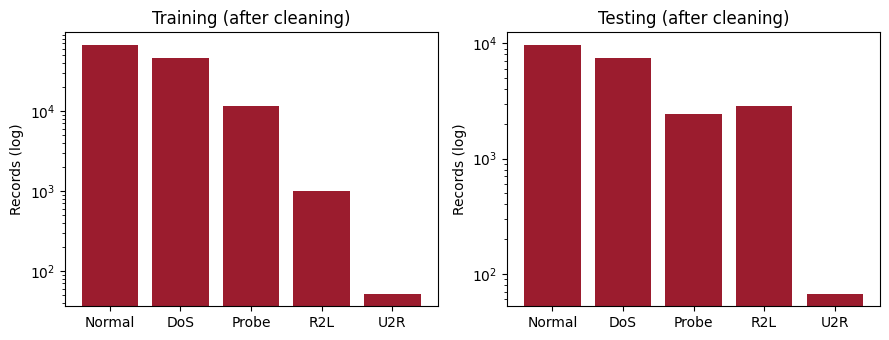

In [9]:
# 3.5 Class distribution after cleaning (Table 1 in the paper)
order = ["Normal", "DoS", "Probe", "R2L", "U2R"]
dist = pd.DataFrame({
    "Train records": train.attack_class.value_counts().reindex(order),
    "Test records":  test.attack_class.value_counts().reindex(order)})
dist["Train %"] = (dist["Train records"] / dist["Train records"].sum() * 100).round(2)
dist["Test %"]  = (dist["Test records"]  / dist["Test records"].sum()  * 100).round(2)
display(dist[["Train records", "Train %", "Test records", "Test %"]])

fig, ax = plt.subplots(1, 2, figsize=(9, 3.5))
for a, col, t in [(ax[0], "Train records", "Training (after cleaning)"), (ax[1], "Test records", "Testing (after cleaning)")]:
    a.bar(dist.index, dist[col], color="#9b1c2e"); a.set_yscale("log"); a.set_title(t); a.set_ylabel("Records (log)")
plt.tight_layout(); plt.show()

## 4. Data Transformation
The three categorical features (`protocol_type`, `service`, `flag`) are one-hot encoded. Numerical features are left unscaled because Random Forest is not affected by feature scale. Class imbalance is handled later by training with `class_weight="balanced_subsample"`.

In [10]:
cat_cols = ["protocol_type", "service", "flag"]
drop_const = ["num_outbound_cmds"]      # the constant feature found in 3.2

# Use the union of categories so train and test get exactly the same encoded columns
all_cats = pd.concat([train[cat_cols], test[cat_cols]])
dummy_cols = pd.get_dummies(all_cats).columns
print("One-hot columns:", len(dummy_cols), "(3 protocol + 70 service + 11 flag)")
print("Services in test but not in train:", sorted(set(test.service) - set(train.service)))

One-hot columns: 84 (3 protocol + 70 service + 11 flag)
Services in test but not in train: []


## 5. Feature Engineering
Nine new features are derived from the original columns (Table 2 in the paper).

In [11]:
def add_engineered(df):
    d = df.copy()
    d["total_bytes"]         = d.src_bytes + d.dst_bytes
    d["bytes_ratio"]         = d.src_bytes / (d.dst_bytes + 1)
    d["log_src_bytes"]       = np.log1p(d.src_bytes)
    d["log_dst_bytes"]       = np.log1p(d.dst_bytes)
    d["log_duration"]        = np.log1p(d.duration)
    d["failed_login_flag"]   = (d.num_failed_logins > 0).astype(int)
    d["srv_count_ratio"]     = d.srv_count / (d["count"] + 1)
    d["error_rate_sum"]      = d.serror_rate + d.rerror_rate
    d["dst_host_error_sum"]  = d.dst_host_serror_rate + d.dst_host_rerror_rate
    return d

engineered = ["total_bytes","bytes_ratio","log_src_bytes","log_dst_bytes","log_duration",
              "failed_login_flag","srv_count_ratio","error_rate_sum","dst_host_error_sum"]
train_e, test_e = add_engineered(train), add_engineered(test)
train_e[engineered].describe().T[["mean", "min", "max"]]

,mean,min,max
total_bytes,65345.857422,0.0,1.379964e+09
bytes_ratio,42832.024695,0.0,1.379964e+09
log_src_bytes,3.229669,0.0,2.104532e+01
log_dst_bytes,3.084400,0.0,2.099325e+01
log_duration,0.321650,0.0,1.066684e+01
failed_login_flag,0.000968,0.0,1.000000e+00
srv_count_ratio,1.125822,0.0,2.555000e+02
error_rate_sum,0.404443,0.0,1.010000e+00
dst_host_error_sum,0.403284,0.0,1.000000e+00


## 6. Feature Selection
Three stages, all using the **training data only**:
1. Remove the constant feature.
2. **Correlation filter:** drop numerical features with |correlation| > 0.95 against an earlier feature.
3. **Importance filter:** after encoding, keep columns whose Random Forest importance is at least 0.001.

In [12]:
# Stage 2: correlation filter on the original numerical features
numeric_cols = [c for c in train.columns if c not in cat_cols + ["label", "attack_class"] + drop_const]
corr = train[numeric_cols].corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
corr_drop = [c for c in upper.columns if (upper[c] > 0.95).any()]
pairs = [(a, b, round(float(upper.loc[a, b]), 3)) for a in upper.index for b in upper.columns
         if pd.notna(upper.loc[a, b]) and upper.loc[a, b] > 0.95]
print("Highly correlated pairs (r > 0.95):")
for p in pairs: print("  ", p)
print("\nDropped by correlation filter:", corr_drop)

Highly correlated pairs (r > 0.95):
   ('num_compromised', 'num_root', 0.999)
   ('serror_rate', 'srv_serror_rate', 0.993)
   ('serror_rate', 'dst_host_serror_rate', 0.979)
   ('serror_rate', 'dst_host_srv_serror_rate', 0.981)
   ('srv_serror_rate', 'dst_host_serror_rate', 0.978)
   ('srv_serror_rate', 'dst_host_srv_serror_rate', 0.986)
   ('rerror_rate', 'srv_rerror_rate', 0.989)
   ('rerror_rate', 'dst_host_srv_rerror_rate', 0.964)
   ('srv_rerror_rate', 'dst_host_srv_rerror_rate', 0.97)
   ('dst_host_serror_rate', 'dst_host_srv_serror_rate', 0.985)

Dropped by correlation filter: ['num_root', 'srv_serror_rate', 'srv_rerror_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_srv_rerror_rate']


In [13]:
def build_matrix(df, drop):
    num = [c for c in df.columns if c not in cat_cols + ["label", "attack_class"] and c not in drop]
    dummies = pd.get_dummies(df[cat_cols]).reindex(columns=dummy_cols, fill_value=0)
    return pd.concat([df[num].reset_index(drop=True), dummies.reset_index(drop=True)], axis=1).astype(float)

X_train_all = build_matrix(train_e, drop_const + corr_drop)
X_test_all  = build_matrix(test_e,  drop_const + corr_drop)
y_train, y_test = train["attack_class"], test["attack_class"]
print("Candidate columns after encoding + engineering + correlation filter:", X_train_all.shape[1])

Candidate columns after encoding + engineering + correlation filter: 124


In [14]:
# Stage 3: importance filter (preliminary forest trained on the training set only)
prelim = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1,
                                class_weight="balanced_subsample").fit(X_train_all, y_train)
importance = pd.Series(prelim.feature_importances_, index=X_train_all.columns).sort_values(ascending=False)
selected = importance[importance >= 0.001].index.tolist()
print(f"Columns kept: {len(selected)} of {len(importance)}")

X_train, X_test = X_train_all[selected], X_test_all[selected]
print("Engineered features kept:", [f for f in engineered if f in selected])

Columns kept: 50 of 124
Engineered features kept: ['total_bytes', 'bytes_ratio', 'log_src_bytes', 'log_dst_bytes', 'log_duration', 'failed_login_flag', 'srv_count_ratio', 'error_rate_sum', 'dst_host_error_sum']


## 7. Training and Testing the Random Forest
- **Training data:** `KDDTrain+` (125,973 records). **Testing data:** `KDDTest+` (22,544 records). The existing NSL-KDD split is used as-is.
- **Settings:** 200 trees, `random_state=42`, `class_weight="balanced_subsample"`, all other parameters at scikit-learn defaults.

In [15]:
rf = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1,
                            class_weight="balanced_subsample")
rf.fit(X_train, y_train)

y_pred  = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)
confidence = y_proba.max(axis=1)
print("Training complete. Predictions generated for", len(y_pred), "test connections.")

Training complete. Predictions generated for 22544 test connections.


## 8. Evaluation

In [16]:
acc = accuracy_score(y_test, y_pred)
print(f"Overall accuracy: {acc:.4f}  ({acc*100:.2f}%)\n")
print(classification_report(y_test, y_pred, labels=order, digits=4, zero_division=0))

for avg in ["macro", "weighted"]:
    p, r, f, _ = precision_recall_fscore_support(y_test, y_pred, labels=order, average=avg, zero_division=0)
    print(f"{avg:>8} avg -> precision {p:.4f} | recall {r:.4f} | F1 {f:.4f}")

Overall accuracy: 0.7388  (73.88%)

              precision    recall  f1-score   support

      Normal     0.6363    0.9727    0.7693      9711
         DoS     0.9606    0.7649    0.8516      7460
       Probe     0.8560    0.6163    0.7166      2421
         R2L     0.8000    0.0014    0.0028      2885
         U2R     0.7000    0.1045    0.1818        67

    accuracy                         0.7388     22544
   macro avg     0.7906    0.4919    0.5044     22544
weighted avg     0.7883    0.7388    0.6911     22544



   macro avg -> precision 0.7906 | recall 0.4919 | F1 0.5044


weighted avg -> precision 0.7883 | recall 0.7388 | F1 0.6911


,Pred Normal,Pred DoS,Pred Probe,Pred R2L,Pred U2R
Actual Normal,9446,68,196,0,1
Actual DoS,1700,5706,54,0,0
Actual Probe,763,166,1492,0,0
Actual R2L,2878,0,1,4,2
Actual U2R,59,0,0,1,7


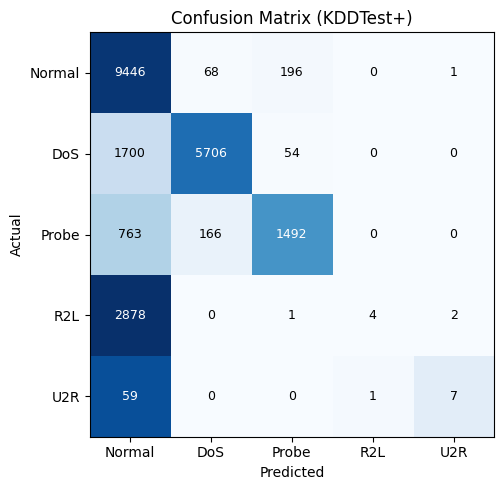

In [17]:
# Confusion matrix (Figure 3 in the paper)
cm = confusion_matrix(y_test, y_pred, labels=order)
cm_df = pd.DataFrame(cm, index=[f"Actual {o}" for o in order], columns=[f"Pred {o}" for o in order])
display(cm_df)

cmn = cm / cm.sum(axis=1, keepdims=True)
fig, ax = plt.subplots(figsize=(6, 5))
ax.imshow(cmn, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(5)); ax.set_yticks(range(5)); ax.set_xticklabels(order); ax.set_yticklabels(order)
for i in range(5):
    for j in range(5):
        ax.text(j, i, cm[i, j], ha="center", va="center", color="white" if cmn[i, j] > 0.5 else "black", fontsize=9)
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual"); ax.set_title("Confusion Matrix (KDDTest+)")
plt.tight_layout(); plt.show()

In [18]:
# False-positive rate per class (one-vs-rest) -- Table 3 in the paper
rows = []
for i, o in enumerate(order):
    FP = cm[:, i].sum() - cm[i, i]
    TN = cm.sum() - cm[i, :].sum() - cm[:, i].sum() + cm[i, i]
    rows.append((o, FP / (FP + TN)))
fpr_table = pd.DataFrame(rows, columns=["Class", "False-positive rate (one-vs-rest)"]).set_index("Class")
display((fpr_table * 100).round(3).astype(str) + "%")

# Normal vs attack view (the conventional intrusion-detection view)
actual_attack = (y_test != "Normal").values
pred_attack   = (pd.Series(y_pred) != "Normal").values
tn = int(((~actual_attack) & (~pred_attack)).sum()); fp = int(((~actual_attack) & pred_attack).sum())
fn = int((actual_attack & (~pred_attack)).sum());   tp = int((actual_attack & pred_attack).sum())
print(f"Normal flagged as attack (false positives): {fp} of {tn+fp}  -> false-positive rate {fp/(fp+tn)*100:.2f}%")
print(f"Attacks detected: {tp} of {tp+fn}  -> detection rate {tp/(tp+fn)*100:.2f}%  ({fn} missed)")
print(f"Binary accuracy (Normal vs attack): {(tp+tn)/(tp+tn+fp+fn)*100:.2f}%")

,False-positive rate (one-vs-rest)
Class,
Normal,42.079%
DoS,1.551%
Probe,1.247%
R2L,0.005%
U2R,0.013%


Normal flagged as attack (false positives): 265 of 9711  -> false-positive rate 2.73%
Attacks detected: 7433 of 12833  -> detection rate 57.92%  (5400 missed)
Binary accuracy (Normal vs attack): 74.87%


**What the results mean.** The model is strong on Normal traffic (high recall) and DoS (high precision), and moderate on Probe. It misses almost all R2L and most U2R attacks, which are predicted as Normal. The causes discussed in the paper are the very small number of R2L/U2R training examples, their similarity to legitimate sessions, and the 17 attack types that appear only in the test file (checked in the next cell).

In [19]:
# Why R2L/U2R fail: attack types that never appear in training
unseen = set(test.label) - set(train.label)
mask_unseen = test.label.isin(unseen).values
print(f"Test records from attack types unseen in training: {mask_unseen.sum()} of {len(test)} ({mask_unseen.mean()*100:.1f}%)")
print(pd.Series(mask_unseen).groupby(y_test.values).mean().reindex(order).mul(100).round(1).rename("% unseen-type records"))
print(f"\nAccuracy on Normal + seen attack types: {accuracy_score(y_test[~mask_unseen], y_pred[~mask_unseen])*100:.2f}%")
print(f"Accuracy on unseen attack types       : {accuracy_score(y_test[mask_unseen], y_pred[mask_unseen])*100:.2f}%")

Test records from attack types unseen in training: 3750 of 22544 (16.6%)
Normal     0.0
DoS       23.0
Probe     54.3
R2L       23.8
U2R       44.8
Name: % unseen-type records, dtype: float64



Accuracy on Normal + seen attack types: 86.55%
Accuracy on unseen attack types       : 10.37%


## 9. Feature Importance (Figure 4 in the paper)

,importance
total_bytes,0.0828
dst_host_srv_count,0.0820
log_src_bytes,0.0659
src_bytes,0.0608
log_dst_bytes,0.0440
bytes_ratio,0.0424
dst_bytes,0.0411
srv_count_ratio,0.0382
dst_host_diff_srv_rate,0.0342
logged_in,0.0334


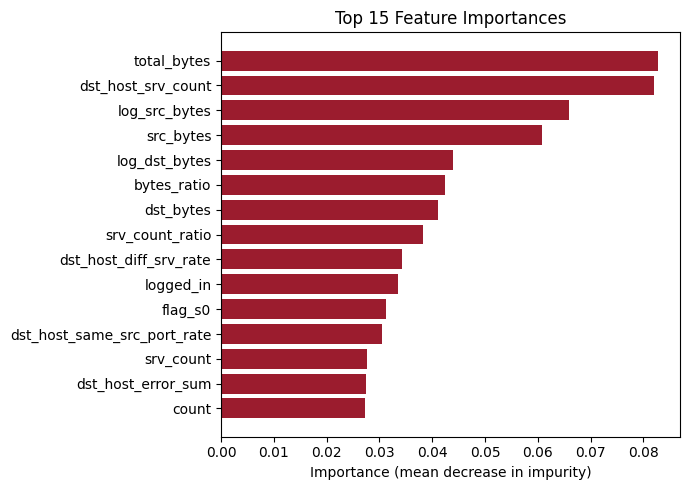

Engineered features in the top 15: ['dst_host_error_sum', 'srv_count_ratio', 'bytes_ratio', 'log_dst_bytes', 'log_src_bytes', 'total_bytes']


In [20]:
final_imp = pd.Series(rf.feature_importances_, index=selected).sort_values(ascending=False)
display(final_imp.head(15).round(4).to_frame("importance"))

top = final_imp.head(15)[::-1]
plt.figure(figsize=(7, 5))
plt.barh(top.index, top.values, color="#9b1c2e")
plt.xlabel("Importance (mean decrease in impurity)"); plt.title("Top 15 Feature Importances")
plt.tight_layout(); plt.show()
print("Engineered features in the top 15:", [f for f in top.index if f in engineered])

## 10. Effect of Preprocessing Steps (supporting experiment, Table 4 in the paper)
The pipeline is re-run at each stage with 100 trees, with and without class weighting, to check whether each step helped. These are single runs, so differences of a few points should be read as indicative only. *This cell takes a few minutes.*

In [21]:
def run_config(drop, engineered_on, class_weight):
    A, B = (train_e, test_e) if engineered_on else (train, test)
    Xa, Xb = build_matrix(A, drop), build_matrix(B, drop)
    m = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1, class_weight=class_weight).fit(Xa, y_train)
    p = m.predict(Xb)
    rec = recall_score(y_test, p, labels=order, average=None, zero_division=0)
    return [accuracy_score(y_test, p), f1_score(y_test, p, average="macro"), rec[3], rec[4]]

configs = [("Baseline (all features)", drop_const, False),
           ("+ correlation filter",    drop_const + corr_drop, False),
           ("+ engineered features",   drop_const + corr_drop, True)]
rows = []
for name, drop, eng in configs:
    for cw in [None, "balanced_subsample"]:
        acc_, mf1, r2l, u2r = run_config(drop, eng, cw)
        rows.append([name, "Balanced" if cw else "None", acc_, mf1, r2l, u2r])
ablation = pd.DataFrame(rows, columns=["Configuration", "Class weight", "Accuracy", "Macro-F1", "R2L recall", "U2R recall"])
display(ablation.style.format({c: "{:.2%}" for c in ["Accuracy", "Macro-F1", "R2L recall", "U2R recall"]}))

,Configuration,Class weight,Accuracy,Macro-F1,R2L recall,U2R recall
0,Baseline (all features),None,76.20%,50.95%,5.06%,2.99%
1,Baseline (all features),Balanced,74.19%,47.84%,0.62%,2.99%
2,+ correlation filter,None,75.31%,51.08%,2.81%,7.46%
3,+ correlation filter,Balanced,73.72%,47.43%,0.62%,1.49%
4,+ engineered features,None,76.44%,52.25%,0.21%,10.45%
5,+ engineered features,Balanced,74.11%,49.16%,0.35%,5.97%


## 11. Prediction Confidence
Each prediction comes with a confidence score: the highest class probability from the forest.

In [22]:
correct = (y_pred == y_test.values)
print(f"Mean confidence (all predictions)  : {confidence.mean()*100:.2f}%")
print(f"Mean confidence (correct)          : {confidence[correct].mean()*100:.2f}%")
print(f"Mean confidence (wrong)            : {confidence[~correct].mean()*100:.2f}%")

Mean confidence (all predictions)  : 93.27%
Mean confidence (correct)          : 97.77%
Mean confidence (wrong)            : 80.54%


## 12. Project Demonstration
The cells below show the trained model producing predictions on connections from the test file, then classifying a hand-made connection record.

In [23]:
# 12.1 Sample predictions: 2 random test connections from each class (10 total)
sample = test.groupby("attack_class", group_keys=False).sample(2, random_state=7)
sample = sample.loc[sorted(sample.index, key=lambda i: order.index(test.attack_class[i]))]
idx = sample.index
demo = pd.DataFrame({
    "protocol": sample.protocol_type.values,
    "service": sample.service.values,
    "flag": sample.flag.values,
    "src_bytes": sample.src_bytes.values,
    "Actual class": y_test.loc[idx].values,
    "Predicted class": y_pred[idx],
    "Confidence": [f"{c*100:.1f}%" for c in confidence[idx]],
})
demo["Correct?"] = np.where(demo["Actual class"] == demo["Predicted class"], "Yes", "No")
display(demo)

,protocol,service,flag,src_bytes,Actual class,Predicted class,Confidence,Correct?
0,tcp,http,sf,153,Normal,Normal,100.0%,Yes
1,tcp,http,sf,204,Normal,Normal,100.0%,Yes
2,tcp,private,s0,0,DoS,DoS,100.0%,Yes
3,tcp,ftp,s0,0,DoS,DoS,100.0%,Yes
4,icmp,eco_i,sf,20,Probe,Probe,81.3%,Yes
5,tcp,other,rej,0,Probe,Probe,100.0%,Yes
6,tcp,ftp,sf,162,R2L,Normal,82.5%,No
7,tcp,ftp_data,sf,283618,R2L,Normal,81.0%,No
8,tcp,telnet,sf,353,U2R,Normal,80.5%,No
9,tcp,ftp_data,sf,0,U2R,Normal,92.5%,No


In [24]:
# 12.2 Classify a single connection record (all 41 raw feature values are needed)
def classify_connection(record: dict):
    row = pd.DataFrame([record])
    for c in ["protocol_type", "service", "flag"]:
        row[c] = row[c].str.strip().str.lower()
    X = build_matrix(add_engineered(row), drop_const + corr_drop)[selected]
    probs = rf.predict_proba(X)[0]
    return rf.classes_[probs.argmax()], {c: round(float(p), 3) for c, p in zip(rf.classes_, probs)}

# Take a real test record and classify it as a dictionary (same input a user would supply)
example = test.drop(columns=["label", "attack_class"]).iloc[0].to_dict()
label, probs = classify_connection(example)
print("Example record -> actual class:", y_test.iloc[0])
print("Predicted class:", label)
print("Class probabilities:", probs)

Example record -> actual class: DoS
Predicted class: DoS
Class probabilities: {'DoS': 1.0, 'Normal': 0.0, 'Probe': 0.0, 'R2L': 0.0, 'U2R': 0.0}


## 13. Save the Model and Conclusion

In [25]:
# Save the trained model and the column list (used by the Streamlit app / project files)
joblib.dump({"model": rf, "selected_columns": selected, "drop": drop_const + corr_drop},
            "nsl_kdd_random_forest.joblib", compress=3)
print("Saved nsl_kdd_random_forest.joblib (", round(os.path.getsize("nsl_kdd_random_forest.joblib")/1e6, 1), "MB )")

Saved nsl_kdd_random_forest.joblib ( 5.2 MB )


### Conclusion
- The Random Forest classified NSL-KDD connections into Normal, DoS, Probe, R2L, and U2R, using the dataset's own training and testing files.
- It performs well on **Normal** and **DoS**, moderately on **Probe**, and poorly on **R2L** and **U2R**.
- Main causes: very few R2L/U2R training examples, similarity of these attacks to normal sessions, and attack types in the test file that never appear in training. Class weighting did not fix this (see Section 10).
- **Recommendations:** tune hyperparameters with cross-validation, try resampling (e.g., SMOTE) inside cross-validation, compare with Logistic Regression / Decision Tree / SVM / MLP, use a two-stage Normal-vs-attack design, add anomaly detection for unseen attacks, and test on newer datasets.